<a href="https://colab.research.google.com/github/nycujack/Machine_Learning_Projects2/blob/main/DEPOSITE%E9%A0%90%E6%B8%AC%E5%88%86%E6%9E%90%E5%B0%88%E6%A1%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 欄位型態
載入分析過程中所需要用到的套件並觀察資料欄位

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn import preprocessing
from google.colab import drive
drive.mount('/content/drive')
bank = pd.read_csv('/content/drive/MyDrive/bank.csv')
bank.head()

Mounted at /content/drive


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


共有17個欄位及11162筆數據

In [ ]:
bank.shape

(11162, 17)

變數名稱

In [ ]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

變數種類

In [ ]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


敘述統計量

In [ ]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


判別資料平衡度

In [ ]:
bank['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


依序建立箱型徒長條圖觀察資料分布

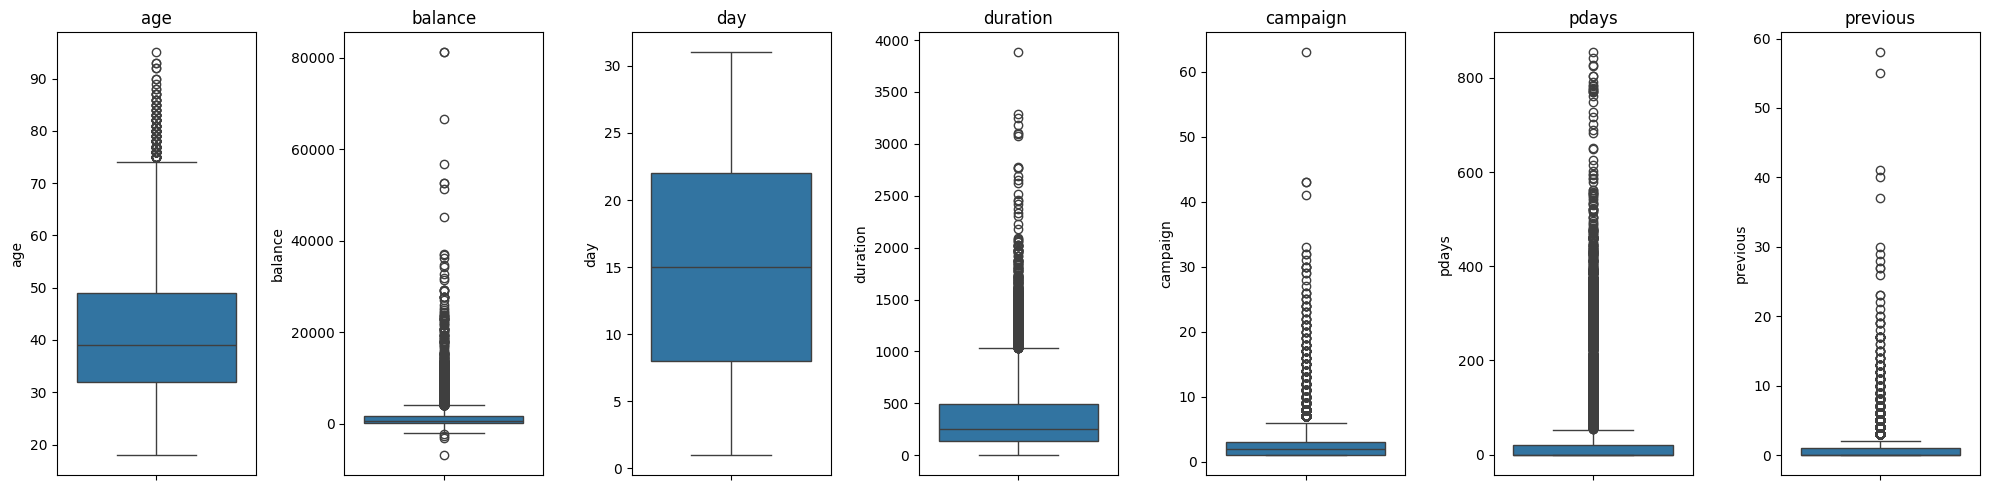

In [ ]:
cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 使用 Seaborn 建立箱型圖
fig, axes = plt.subplots(1, 7, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    sn.boxplot(y=bank[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout() # 調整子圖之間的間距
plt.show() # 顯示圖表

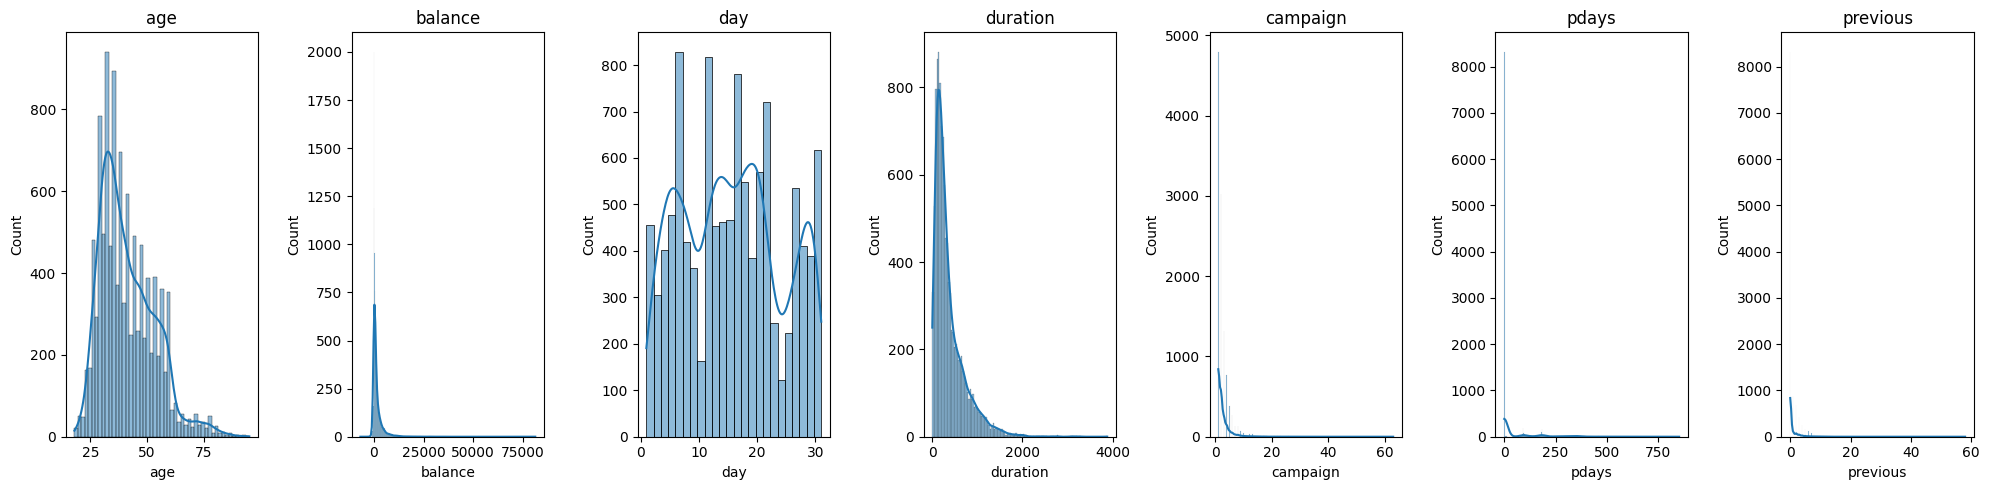

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 使用 Seaborn 建立直方圖
fig, axes = plt.subplots(1, 7, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    # 使用histplot取代distplot，並使用x參數指定資料欄位
    sns.histplot(x=bank[col], ax=axes[i], kde=True)  # kde=True 添加核密度估計曲線
    axes[i].set_title(col)

plt.tight_layout() # 調整子圖之間的間距
plt.show() # 顯示圖表

# 遺漏值和相關性
建立HEATmap來觀察變數間的交叉作用何缺失值

<Axes: >

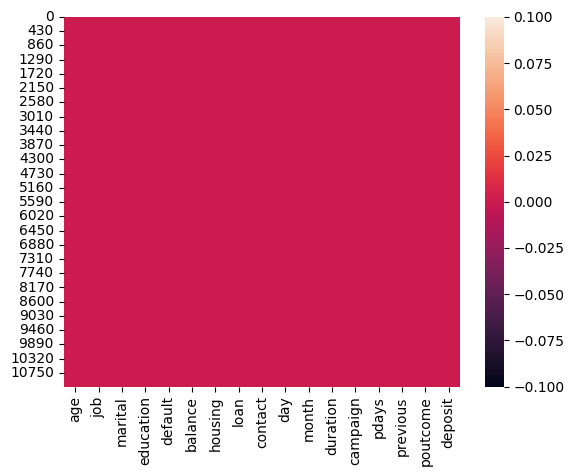

In [ ]:
sn.heatmap(bank.isnull())

經過檢查我們的數據集中沒有任何缺失值。如果存在缺失值，在紅色背景上會顯示不同的顏色陰影。 保險起見使用 isna() 方法再度檢查缺失值。

In [ ]:
bank.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


# 獨熱編碼(OneHot Encoding)、標籤編碼(Label Encoding)

相關性分析僅適用於連續型變量，而我們的數據集中有一些類別型變量。 因此我們需要將其轉換為數值。 數據中的類別型變量包括：job、marital、education、default、housing、loan、contact、month、poutcome 以及輸出變量 y

In [ ]:
bank['job'].describe()

,job
count,11162
unique,12
top,management
freq,2566


In [ ]:
label_encoder = preprocessing.LabelEncoder()

bank['job']= label_encoder.fit_transform(bank['job'])

bank['job'].unique()

array([ 0,  9,  7,  4,  5,  1, 10,  2,  3, 11,  6,  8])

In [ ]:
bank['marital'].describe()

,marital
count,11162
unique,3
top,married
freq,6351


In [ ]:
bank = pd.get_dummies(bank, columns=['marital'])
bank.head()

,age,job,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,marital_divorced,marital_married,marital_single
0,59,0,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,False,True,False
1,56,0,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,False,True,False
2,41,9,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,False,True,False
3,55,7,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,False,True,False
4,54,0,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,False,True,False


In [ ]:
bank['education'].describe()

,education
count,11162
unique,4
top,secondary
freq,5476


我們可以看到 education 欄位有 3 個唯一值，可以使用獨熱編碼 (One-Hot Encoding) 或標籤編碼 (Label Encoding)處理。 但由於這些值是有序的（例如：primary, secondary, tertiary），因此我們選擇使用標籤編碼以防止多重共線性問題

In [ ]:
bank['education']= label_encoder.fit_transform(bank['education'])

bank['education'].unique()

array([1, 2, 0, 3])

In [ ]:
bank['default'].describe()

,default
count,11162
unique,2
top,no
freq,10994


我們可以看到 default 欄位只有 2 個唯一值，由於 default 欄位的值不是有序的，因此我們選擇使用獨熱編碼。

In [ ]:
bank['default']= label_encoder.fit_transform(bank['default'])

bank['default'].unique()
bank.head()

,age,job,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,marital_divorced,marital_married,marital_single
0,59,0,1,0,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,False,True,False
1,56,0,1,0,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,False,True,False
2,41,9,1,0,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,False,True,False
3,55,7,1,0,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,False,True,False
4,54,0,2,0,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,False,True,False


In [ ]:
bank['housing'].describe()

,housing
count,11162
unique,2
top,no
freq,5881


們看到 housing 欄位只有兩個唯一值，由於 housing 欄位的值不是有序的（“yes” 和 “no” 之間沒有固定的順序），因此我們選擇使用獨熱編碼。

In [ ]:
bank = pd.get_dummies(bank, columns=['housing'])
bank.head()

,age,job,education,default,balance,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,marital_divorced,marital_married,marital_single,housing_no,housing_yes
0,59,0,1,0,2343,no,unknown,5,may,1042,1,-1,0,unknown,yes,False,True,False,False,True
1,56,0,1,0,45,no,unknown,5,may,1467,1,-1,0,unknown,yes,False,True,False,True,False
2,41,9,1,0,1270,no,unknown,5,may,1389,1,-1,0,unknown,yes,False,True,False,False,True
3,55,7,1,0,2476,no,unknown,5,may,579,1,-1,0,unknown,yes,False,True,False,False,True
4,54,0,2,0,184,no,unknown,5,may,673,2,-1,0,unknown,yes,False,True,False,True,False


loan 欄位由於只有兩個唯一值（yes/no），類似於 housing 欄位，因此使用獨熱編碼。

In [ ]:
bank = pd.get_dummies(bank, columns=['loan'])
bank.head()

,age,job,education,default,balance,contact,day,month,duration,campaign,...,previous,poutcome,deposit,marital_divorced,marital_married,marital_single,housing_no,housing_yes,loan_no,loan_yes
0,59,0,1,0,2343,unknown,5,may,1042,1,...,0,unknown,yes,False,True,False,False,True,True,False
1,56,0,1,0,45,unknown,5,may,1467,1,...,0,unknown,yes,False,True,False,True,False,True,False
2,41,9,1,0,1270,unknown,5,may,1389,1,...,0,unknown,yes,False,True,False,False,True,True,False
3,55,7,1,0,2476,unknown,5,may,579,1,...,0,unknown,yes,False,True,False,False,True,True,False
4,54,0,2,0,184,unknown,5,may,673,2,...,0,unknown,yes,False,True,False,True,False,True,False


我們可以看到 contact 欄位只有 3 個唯一值，但由於 contact 欄位的值不是有序的，因此選擇使用獨熱編碼。

In [ ]:
bank = pd.get_dummies(bank, columns=['contact'])
bank.head()

,age,job,education,default,balance,day,month,duration,campaign,pdays,...,marital_divorced,marital_married,marital_single,housing_no,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown
0,59,0,1,0,2343,5,may,1042,1,-1,...,False,True,False,False,True,True,False,False,False,True
1,56,0,1,0,45,5,may,1467,1,-1,...,False,True,False,True,False,True,False,False,False,True
2,41,9,1,0,1270,5,may,1389,1,-1,...,False,True,False,False,True,True,False,False,False,True
3,55,7,1,0,2476,5,may,579,1,-1,...,False,True,False,False,True,True,False,False,False,True
4,54,0,2,0,184,5,may,673,2,-1,...,False,True,False,True,False,True,False,False,False,True


In [ ]:
bank['month'].describe()

,month
count,11162
unique,12
top,may
freq,2824


month 欄位有 12 個唯一值且有時序性因此我們將使用標籤編碼

In [ ]:
bank['month']= label_encoder.fit_transform(bank['month'])

bank['month'].unique()

array([ 8,  6,  5,  1, 10,  9,  2,  4,  3,  7,  0, 11])

In [ ]:
bank['poutcome'].describe()

,poutcome
count,11162
unique,4
top,unknown
freq,8326


我們看到 poutcome 欄位只有 4 個唯一值，由於 poutcome 欄位的值不是有序的，因此使用獨熱編碼。

In [ ]:
bank = pd.get_dummies(bank, columns=['poutcome'])
bank.head()

,age,job,education,default,balance,day,month,duration,campaign,pdays,...,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,1,0,2343,5,8,1042,1,-1,...,True,True,False,False,False,True,False,False,False,True
1,56,0,1,0,45,5,8,1467,1,-1,...,False,True,False,False,False,True,False,False,False,True
2,41,9,1,0,1270,5,8,1389,1,-1,...,True,True,False,False,False,True,False,False,False,True
3,55,7,1,0,2476,5,8,579,1,-1,...,True,True,False,False,False,True,False,False,False,True
4,54,0,2,0,184,5,8,673,2,-1,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
bank['deposit'].describe()

,deposit
count,11162.000000
mean,0.473840
std,0.499338
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
bank['deposit'].value_counts()

,count
deposit,
0,5873
1,5289


此處可以看到 deposit 欄位只有兩個唯一值（yes/no）。 而deposit 欄位實際上是我們的輸出變量，也就是我們需要預測的目標。

In [ ]:
bank['deposit']= label_encoder.fit_transform(bank['deposit'])

bank['deposit'].unique()

array([1, 0])

In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [ ]:
bank.head()

,age,job,education,default,balance,day,month,duration,campaign,pdays,previous,deposit,marital_divorced,marital_married,marital_single,housing_no,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,1,0,2343,5,8,1042,1,-1,0,1,False,True,False,False,True,True,False,False,False,True,False,False,False,True
1,56,0,1,0,45,5,8,1467,1,-1,0,1,False,True,False,True,False,True,False,False,False,True,False,False,False,True
2,41,9,1,0,1270,5,8,1389,1,-1,0,1,False,True,False,False,True,True,False,False,False,True,False,False,False,True
3,55,7,1,0,2476,5,8,579,1,-1,0,1,False,True,False,False,True,True,False,False,False,True,False,False,False,True
4,54,0,2,0,184,5,8,673,2,-1,0,1,False,True,False,True,False,True,False,False,False,True,False,False,False,True


建立完整heatmap

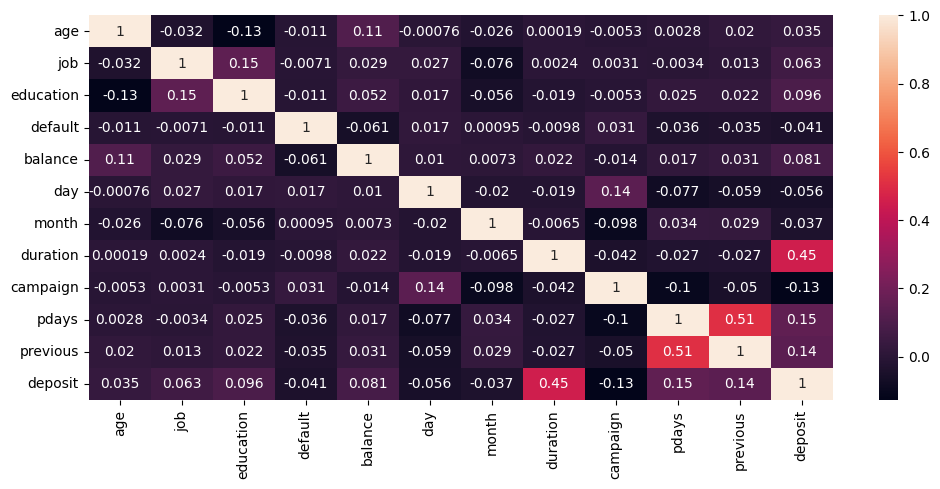

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn  # 導入seaborn，用於數據可視化
import matplotlib.pyplot as plt  # 導入matplotlib.pyplot，用於繪圖

# 選擇數值型特徵進行相關性分析
numerical_features = bank.select_dtypes(include=np.number).columns


# 計算數值型特徵的相關性矩陣
correlation_matrix = bank[numerical_features].corr()


# 生成熱力圖
plt.figure(figsize=(12, 5))
sn.heatmap(correlation_matrix, annot=True)
plt.show()

In [ ]:
bank.corr()

,age,job,education,default,balance,day,month,duration,campaign,pdays,previous,deposit,marital_divorced,marital_married,marital_single,housing_no,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
age,1.000000,-0.031603,-0.126018,-0.011425,0.112300,-0.000762,-0.026130,0.000189,-0.005278,0.002774,0.020169,0.034901,0.186349,0.318436,-0.467799,0.168700,-0.168700,0.031418,-0.031418,-0.085019,0.210912,-0.037860,-0.008071,-0.018715,0.062114,-0.027021
job,-0.031603,1.000000,0.147046,-0.007066,0.028736,0.026589,-0.076011,0.002432,0.003104,-0.003385,0.012665,0.063395,0.000012,-0.098936,0.105451,0.136965,-0.136965,0.067092,-0.067092,0.081233,-0.003679,-0.087180,-0.006760,-0.004934,0.043148,-0.021907
education,-0.126018,0.147046,1.000000,-0.010709,0.051728,0.016759,-0.055868,-0.019122,-0.005327,0.025165,0.022427,0.095948,-0.031644,-0.118059,0.147641,0.109168,-0.109168,0.073154,-0.073154,0.131515,-0.037512,-0.121466,0.013684,0.016125,0.070051,-0.065154
default,-0.011425,-0.007066,-0.010709,1.000000,-0.060954,0.017342,0.000950,-0.009760,0.030975,-0.036282,-0.035273,-0.040680,0.019633,-0.006819,-0.006255,-0.011076,0.011076,-0.076434,0.076434,-0.026301,-0.022157,0.042784,-0.024650,-0.017475,-0.040272,0.053554
balance,0.112300,0.028736,0.051728,-0.060954,1.000000,0.010467,0.007264,0.022436,-0.013894,0.017411,0.030805,0.081129,-0.017586,0.025431,-0.014994,0.077092,-0.077092,0.084589,-0.084589,0.007816,0.060350,-0.046237,0.001695,0.028521,0.045603,-0.046091
day,-0.000762,0.026589,0.016759,0.017342,0.010467,1.000000,-0.019840,-0.018511,0.137007,-0.077232,-0.058981,-0.056326,0.001368,0.002832,-0.003961,0.014770,-0.014770,-0.017269,0.017269,-0.011402,0.014687,0.003401,-0.068381,-0.007526,-0.044280,0.082807
month,-0.026130,-0.076011,-0.055868,0.000950,0.007264,-0.019840,1.000000,-0.006482,-0.098123,0.033631,0.029283,-0.037121,0.024531,-0.026565,0.011419,-0.219602,0.219602,-0.025329,0.025329,-0.268225,0.013703,0.286889,0.034954,0.005595,0.025031,-0.044808
duration,0.000189,0.002432,-0.019122,-0.009760,0.022436,-0.018511,-0.006482,1.000000,-0.041557,-0.027392,-0.026716,0.451919,0.021364,-0.036179,0.023847,-0.035051,0.035051,0.001914,-0.001914,0.020938,-0.015966,-0.013107,-0.033966,-0.008782,-0.022578,0.044006
campaign,-0.005278,0.003104,-0.005327,0.030975,-0.013894,0.137007,-0.098123,-0.041557,1.000000,-0.102726,-0.049699,-0.128081,-0.006828,0.047722,-0.046165,-0.006660,0.006660,-0.034722,0.034722,-0.067236,0.046576,0.045016,-0.080188,-0.023689,-0.091807,0.131392
pdays,0.002774,-0.003385,0.025165,-0.036282,0.017411,-0.077232,0.033631,-0.027392,-0.102726,1.000000,0.507272,0.151593,-0.015574,-0.019280,0.031280,-0.064497,0.064497,0.030416,-0.030416,0.205877,0.006710,-0.230944,0.602615,0.341404,0.329567,-0.823928


In [ ]:
Y = bank['deposit']
Y.head()

,deposit
0,1
1,1
2,1
3,1
4,1


去除反應變數也就是預測目標deposit

In [ ]:
X = bank.drop('deposit',axis=1)
X.head()

,age,job,education,default,balance,day,month,duration,campaign,pdays,previous,marital_divorced,marital_married,marital_single,housing_no,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,1,0,2343,5,8,1042,1,-1,0,False,True,False,False,True,True,False,False,False,True,False,False,False,True
1,56,0,1,0,45,5,8,1467,1,-1,0,False,True,False,True,False,True,False,False,False,True,False,False,False,True
2,41,9,1,0,1270,5,8,1389,1,-1,0,False,True,False,False,True,True,False,False,False,True,False,False,False,True
3,55,7,1,0,2476,5,8,579,1,-1,0,False,True,False,False,True,True,False,False,False,True,False,False,False,True
4,54,0,2,0,184,5,8,673,2,-1,0,False,True,False,True,False,True,False,False,False,True,False,False,False,True


# 建立模型
使用羅吉斯回歸模型建模

In [ ]:
classifier = LogisticRegression()
classifier.fit(X,Y)
y_pred = classifier.predict(X)
y_pred_df= pd.DataFrame({'actual': Y,'predicted_prob': classifier.predict(X)})
y_pred_df

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,actual,predicted_prob
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


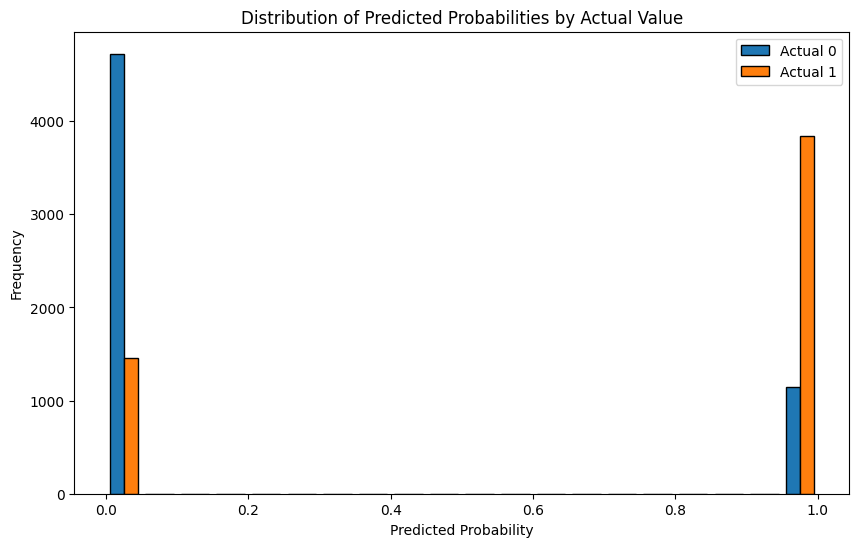

In [ ]:


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist([y_pred_df[y_pred_df['actual'] == 0]['predicted_prob'],
          y_pred_df[y_pred_df['actual'] == 1]['predicted_prob']],
         bins=20, edgecolor='black', label=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities by Actual Value')
_ = plt.legend()

# 模型精確性
使用混淆矩陣和ROC曲線來估計其精確性

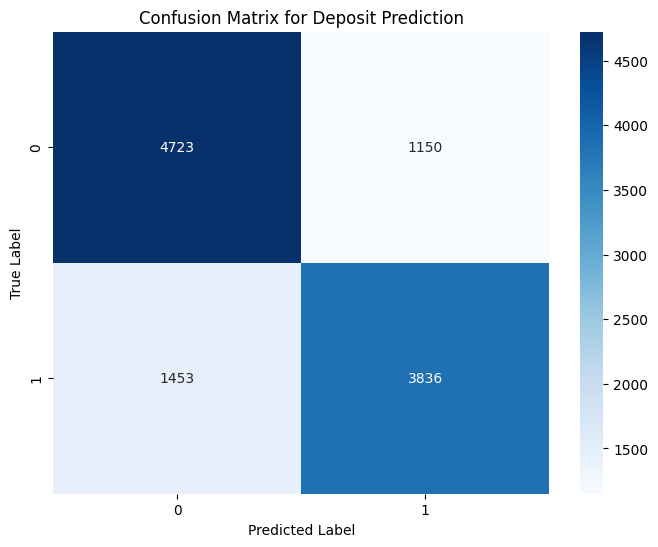

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

confusion_matrix = confusion_matrix(Y, y_pred)

# Create a heatmap for the confusion matrix with a title
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Deposit Prediction")  # Add title here
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

整體來說，此模型在兩個類別上的預測能力都比較均衡。精確率、召回率和 F1-score 都在 0.75 以上，說明模型具有較好的準確性和泛化能力。

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78      5873
           1       0.77      0.73      0.75      5289

    accuracy                           0.77     11162
   macro avg       0.77      0.76      0.77     11162
weighted avg       0.77      0.77      0.77     11162



畫出ROC及計算出AUC，最終AUC值約在0.764，表示模型具有良好的區分能力，性能良好

Text(0, 0.5, 'True Positive Rate')

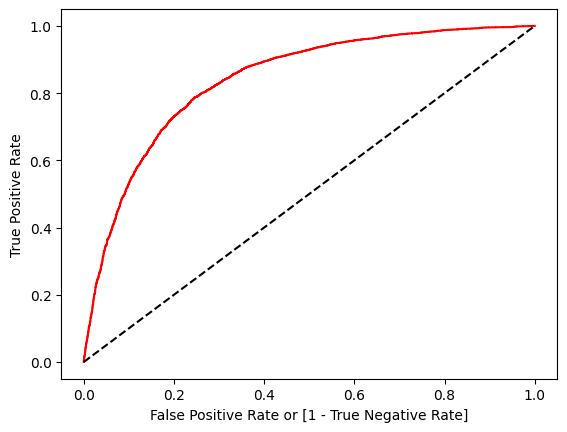

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(Y, classifier.predict_proba (X)[:,1])

auc = roc_auc_score(Y, y_pred)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

In [ ]:
auc

np.float64(0.7647337703325675)

# 分析統整

影響較大的因子 (負相關)
housing_yes: 係數為 -0.192621，表示擁有房屋貸款的客戶，訂閱定期存款的可能性較低。這可能是因為擁有房屋貸款的客戶，資金流動性較差，或者有其他投資規劃，因此較少選擇定期存款。
campaign: 係數為 -0.302697，表示在本次營銷活動中與客戶聯繫的次數越多，客戶訂閱定期存款的可能性反而越低。這可能是因為過於頻繁的聯繫會引起客戶的反感，導致他們降低訂閱意願。
contact_unknown: 係數為 -0.130265，表示聯繫方式未知的客戶，訂閱定期存款的可能性較低。這可能是因為銀行難以聯繫上這些客戶，無法有效地推廣定期存款產品。
poutcome_unknown: 係數為 -0.118453，表示上次營銷活動結果未知的客戶，訂閱定期存款的可能性較低。這可能是因為缺乏上次營銷活動的信息，銀行難以評估這些客戶的潛在需求。

影響較大的因子 (正相關)
previous: 係數為 0.173220，表示上次營銷活動中與客戶聯繫的次數越多，客戶訂閱定期存款的可能性越高。這可能是因為之前的聯繫已經建立了一定的信任基礎，客戶更容易接受本次營銷活動的推廣。
housing_no: 係數為 0.143136，表示沒有房屋貸款的客戶，訂閱定期存款的可能性較高。這可能是因為沒有房屋貸款的客戶，資金流動性較好，更容易進行投資理財。
poutcome_success: 係數為 0.108594，表示上次營銷活動成功的客戶，訂閱定期存款的可能性較高。這可能是因為上次營銷活動的成功經驗，提升了客戶對銀行產品和服務的信任度。

In [ ]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': classifier.coef_[0]})
print(coefficients)


              Feature  Coefficient
0                 age    -0.014633
1                 job     0.036543
2           education     0.035107
3             default    -0.006111
4             balance     0.000051
5                 day    -0.018762
6               month    -0.058057
7            duration     0.004432
8            campaign    -0.302697
9               pdays     0.000868
10           previous     0.173220
11   marital_divorced     0.003039
12    marital_married    -0.065087
13     marital_single     0.012564
14         housing_no     0.143136
15        housing_yes    -0.192621
16            loan_no     0.008245
17           loan_yes    -0.057730
18   contact_cellular     0.065617
19  contact_telephone     0.015164
20    contact_unknown    -0.130265
21   poutcome_failure    -0.034038
22     poutcome_other    -0.005587
23   poutcome_success     0.108594
24   poutcome_unknown    -0.118453
